# Model Predictions (qubit-TransmonCross-Hamiltonian_params)
## Quantum Metal --> Hamiltonian

Ansys surrogate model

## Configuration

In [1]:
## the parameter file has the hyperparameters
## start there if you want to change the setup

from parameters_surrogate import *

## Library

In [2]:
import os, gc, math
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras.models import load_model

## Dataset

### Load

In [3]:
def load_scaled_split(kind, split):
    return np.load(f"{DATA_DIR}/npy/{split}_{kind}_encoding_scaled.npy", allow_pickle=True)

## new inputs are our qiskit metal params, using good ole linear encoding
X_train = load_scaled_split('linear', 'y_train')
X_val   = load_scaled_split('linear', 'y_val')
X_test  = load_scaled_split('linear', 'y_test')

## new outputs are the hamiltonian values
y_train = load_scaled_split('linear', 'x_train')
y_val   = load_scaled_split('linear', 'x_val')
y_test  = load_scaled_split('linear', 'x_test')

## load column name files for later reference fer outputs
with open(str(Path(METADATA_DIR) / 'X_names'), 'r') as f:
    Hamiltonian_column_names = f.read().splitlines()   

## input names
qiskit_param_names = np.load(str(Path(METADATA_DIR) / 'y_columns.npy'), allow_pickle=True).astype(str).tolist() 

## check to make sure these printouts make sense and we arent flippered
print(f'Inputs (Qiskit params):  {X_train.shape[1]} columns')
print(f'Outputs (Hamiltonian):    {y_train.shape[1]} columns')
print(f'\nInput columns:  {qiskit_param_names}')
print(f'Output columns: {Hamiltonian_column_names}')

Inputs (Qiskit params):  3 columns
Outputs (Hamiltonian):    1 columns

Input columns:  ['design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.cross_length']
Output columns: ['EC_GHz']


### Visualize model

In [4]:
## decide which model file to use
encoding = 'model2_surrogate'
chosen_path = f'{MODEL_DIR}/best_keras_model_model2_surrogate.keras'
X_test_cur = np.asarray(X_test)
y_test_cur = np.asarray(y_test)

## load output headers (hamiltonian column names)
headers = Hamiltonian_column_names
print(f'Model path: {chosen_path}')
print(f'Output headers: {headers}')

Model path: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/best_keras_model_model2_surrogate.keras
Output headers: ['EC_GHz']


In [5]:
## look at the saved model
tf.keras.backend.clear_session()
gc.collect()
try:
    tf.config.experimental.reset_memory_stats('GPU:0')
except Exception:
    pass

with tf.device('/CPU:0'):
    chosen_model = load_model(chosen_path, compile=False)
    y_pred = chosen_model.predict(X_test_cur, verbose=0)

print(f'\n-- {os.path.basename(chosen_path)} --')
chosen_model.summary()
print(f'Samples: {len(X_test_cur)} | Targets dim: {y_test_cur.shape[1]}')

I0000 00:00:1780849539.972598  235953 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38660 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:00:10.0, compute capability: 8.0
I0000 00:00:1780849540.168685  236618 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



-- best_keras_model_model2_surrogate.keras --


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc0 (Dense)                     │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu0 (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

Samples: 291 | Targets dim: 1


In [6]:
## look at a few more model details
m = tf.keras.models.load_model(chosen_path, compile=True)

neurons_per_layer = [
    l.units for l in m.layers
    if isinstance(l, tf.keras.layers.Dense) and l.name.startswith('fc')
]
print('Best NEURONS_PER_LAYER:', neurons_per_layer)

dropouts = [
    (l.name, float(l.rate)) for l in m.layers
    if isinstance(l, tf.keras.layers.Dropout)
]
if dropouts:
    print('Best DROPOUT rate(s):', dropouts)
else:
    print('Best DROPOUT rate(s): none found')

opt = getattr(m, 'optimizer', None)
if opt is None:
    print('Best learning rate: (no optimizer found on loaded model)')
else:
    lr_obj = opt.learning_rate

    if isinstance(lr_obj, tf.keras.optimizers.schedules.LearningRateSchedule):
        print('Best learning rate: (schedule)', type(lr_obj).__name__)
        try:
            cfg = lr_obj.get_config()
            print('LR schedule config:')
            for k, v in sorted(cfg.items()):
                print(f'  {k}: {v}')
        except Exception as e:
            print('Could not read LR schedule config:', repr(e))
        try:
            step = int(tf.keras.backend.get_value(opt.iterations))
            current_lr = float(lr_obj(step).numpy())
            print(f'Current LR at step {step}:', current_lr)
        except Exception as e:
            print('Could not compute current LR from schedule:', repr(e))
    else:
        try:
            lr_val = float(tf.keras.backend.get_value(lr_obj))
            print('Best learning rate:', lr_val)
        except Exception as e:
            print('Best learning rate: (unreadable)', repr(e))

Best NEURONS_PER_LAYER: [512]
Best DROPOUT rate(s): [('dropout0', 0.0)]
Best learning rate: 0.039520520716905594


/home/olivias/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Scaled

In [7]:
N_SAMPLES_TO_SHOW = 3 ## change this to print more stuff

X_test_cur = np.asarray(X_test_cur)
y_test_cur = np.asarray(y_test_cur)
y_pred     = np.asarray(y_pred)

N, P = y_test_cur.shape

## make sure the prediction shape matches
if y_pred.ndim == 3 and y_pred.shape[-1] == 1:
    y_pred = y_pred[..., 0]
if y_pred.ndim == 1:
    y_pred = y_pred.reshape(-1, 1)
assert y_pred.shape == (N, P), f'y_pred shape {y_pred.shape} != expected {(N, P)}'

## scaled errors
sq_errors  = (y_test_cur - y_pred) ** 2
abs_errors = np.abs(y_test_cur - y_pred)

## building dataframe
rows = []
for i in range(N_SAMPLES_TO_SHOW):
    for j in range(P):
        label = headers[j] if j < len(headers) else f'Hamiltonian_col_{j}'
        rows.append({
            'sample_idx': i,
            'param': label,
            'ref':  y_test_cur[i, j],
            'pred': y_pred[i, j],
            'abs_error': abs_errors[i, j],
            'sq_error':  sq_errors[i, j],
        })

df = pd.DataFrame(rows)

## save scaled predictions
out_csv = Path(RESULTS_DIR) / 'predictions' / f'model2_predictions_and_errors_{encoding}.csv'
df.to_csv(out_csv, index=False, float_format='%.6g')
print(f'Saved CSV -> {out_csv.resolve()}\n')

## pretty print persample (scaled)
for i in range(N_SAMPLES_TO_SHOW):
    sub = df[df['sample_idx'] == i].copy()
    sub = sub[['param', 'ref', 'pred', 'abs_error', 'sq_error']]
    input_str = ', '.join(
        f'{qiskit_param_names[k] if k < len(qiskit_param_names) else f"in_{k}"}={X_test_cur[i,k]:.6g}'
        for k in range(X_test_cur.shape[1])
    )
    print(f'- Sample {i} - Inputs: {input_str}')
    print(sub.to_string(index=False))
    print()

print('Global scaled error stats:')
print('  min abs_error:', float(abs_errors.min()))
print('  median abs_error:', float(np.median(abs_errors)))
print('  max abs_error:', float(abs_errors.max()))

Saved CSV -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/predictions/model2_predictions_and_errors_model2_surrogate.csv

- Sample 0 - Inputs: design_options.connection_pads.readout.claw_length=0.333333, design_options.connection_pads.readout.ground_spacing=0.152542, design_options.cross_length=0.515152
 param      ref     pred  abs_error  sq_error
EC_GHz 0.161252 0.162938   0.001687  0.000003

- Sample 1 - Inputs: design_options.connection_pads.readout.claw_length=0.0909091, design_options.connection_pads.readout.ground_spacing=1, design_options.cross_length=0.606061
 param      ref     pred  abs_error     sq_error
EC_GHz 0.130132 0.130197   0.000065 4.276717e-09

- Sample 2 - Inputs: design_options.connection_pads.readout.claw_length=0.121212, design_options.connection_pads.readout.ground_spacing=0, design_options.cross_length=0.272727
 param     ref     pred  abs_error  sq_error
EC_GHz 0.37633 0.378203   0.001874  0.000004

G

# Unscaled

In [8]:
## unscale everything and look at errors in real units that we can actually understand

## load output hamiltonian column names
with open(str(Path(METADATA_DIR) / 'X_names'), 'r') as f:
    Hamiltonian_names = f.read().splitlines()  

qiskit_names = np.load(str(Path(METADATA_DIR) / 'y_columns.npy'), allow_pickle=True).astype(str).tolist()  ## our inputs

## unscale inputs
X_test_unscaled = np.asarray(X_test_cur.copy())
for i in range(X_test_unscaled.shape[0]):
    for j in range(X_test_unscaled.shape[1]):
        param_name = qiskit_names[j] if j < len(qiskit_names) else f'col_{j}'
        scaler = joblib.load(f'{SCALERS_DIR}/scaler_y_linear_{param_name}.save')
        X_test_unscaled[i, j] = scaler.inverse_transform([[X_test_unscaled[i, j]]])[0][0]

## unscale outputs
y_test_unscaled = np.asarray(y_test_cur.copy())
for i in range(y_test_unscaled.shape[0]):
    for j in range(y_test_unscaled.shape[1]):
        Hamiltonian_name = Hamiltonian_names[j] if j < len(Hamiltonian_names) else f'col_{j}'
        scaler = joblib.load(f'{SCALERS_DIR}/scaler_X_linear_{Hamiltonian_name}.save')
        y_test_unscaled[i, j] = scaler.inverse_transform([[y_test_unscaled[i, j]]])[0][0]

## unscale predictions using same X scalers
y_pred_unscaled = np.asarray(y_pred.copy())
for i in range(y_pred_unscaled.shape[0]):
    for j in range(y_pred_unscaled.shape[1]):
        Hamiltonian_name = Hamiltonian_names[j] if j < len(Hamiltonian_names) else f'col_{j}'
        scaler = joblib.load(f'{SCALERS_DIR}/scaler_X_linear_{Hamiltonian_name}.save')
        y_pred_unscaled[i, j] = scaler.inverse_transform([[y_pred_unscaled[i, j]]])[0][0]

n_samples, n_params = y_test_unscaled.shape

sq_errors_unscaled  = (y_test_unscaled - y_pred_unscaled) ** 2
abs_errors_unscaled = np.abs(y_test_unscaled - y_pred_unscaled)

## build dataframe
rows_unscaled = []
for i in range(N_SAMPLES_TO_SHOW):
    for j in range(n_params):
        Hamiltonian_name = Hamiltonian_names[j] if j < len(Hamiltonian_names) else f'col_{j}'
        rows_unscaled.append({
            'sample_idx': i,
            'param': Hamiltonian_name,
            'ref_unscaled': y_test_unscaled[i, j],
            'pred_unscaled': y_pred_unscaled[i, j],
            'abs_error_unscaled': abs_errors_unscaled[i, j],
            'sq_error_unscaled': sq_errors_unscaled[i, j],
        })

df_unscaled = pd.DataFrame(rows_unscaled)

out_csv_unscaled = Path(RESULTS_DIR) / 'predictions' / f'model2_predictions_and_errors_unscaled_{encoding}.csv'
df_unscaled.to_csv(out_csv_unscaled, index=False, float_format='%.6g')
print(f'Saved CSV -> {out_csv_unscaled.resolve()}\n')

## pretty print persample
for i in range(N_SAMPLES_TO_SHOW):
    sub = df_unscaled[df_unscaled['sample_idx'] == i].copy()
    sub = sub[['param', 'ref_unscaled', 'pred_unscaled', 'abs_error_unscaled', 'sq_error_unscaled']]
    input_str = ', '.join(
        f'{qiskit_names[k] if k < len(qiskit_names) else f"col_{k}"}={X_test_unscaled[i,k]:.6g}'
        for k in range(X_test_unscaled.shape[1])
    )
    print(f'- Sample {i} (Unscaled) - Inputs: {input_str}')
    print(sub.to_string(index=False))
    print()

print('Global unscaled error stats:')
print('  min abs_error:', float(abs_errors_unscaled.min()))
print('  median abs_error:', float(np.median(abs_errors_unscaled)))
print('  max abs_error:', float(abs_errors_unscaled.max()))

Saved CSV -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/predictions/model2_predictions_and_errors_unscaled_model2_surrogate.csv

- Sample 0 (Unscaled) - Inputs: design_options.connection_pads.readout.claw_length=0.00018, design_options.connection_pads.readout.ground_spacing=5e-06, design_options.cross_length=0.00026
 param  ref_unscaled  pred_unscaled  abs_error_unscaled  sq_error_unscaled
EC_GHz      0.138851       0.139429            0.000578       3.341887e-07

- Sample 1 (Unscaled) - Inputs: design_options.connection_pads.readout.claw_length=0.0001, design_options.connection_pads.readout.ground_spacing=1e-05, design_options.cross_length=0.00029
 param  ref_unscaled  pred_unscaled  abs_error_unscaled  sq_error_unscaled
EC_GHz      0.128185       0.128208            0.000022       5.021612e-10

- Sample 2 (Unscaled) - Inputs: design_options.connection_pads.readout.claw_length=0.00011, design_options.connection_pads.readout.g

## Visualize Results

Lets see how good we actually did

In [9]:
## find percentage difference like 100 * abs(pred re) / abs(ref), with tiny epsilon to avoid division by zero
eps = 1e-15
pct_errors_unscaled = 100.0 * np.abs(y_pred_unscaled - y_test_unscaled) / (np.abs(y_test_unscaled) + eps)

short_names = [c.split('.')[-1] if '.' in c else c for c in Hamiltonian_names[:n_params]]
data_per_col = [pct_errors_unscaled[:, j] for j in range(n_params)]
all_pct = pct_errors_unscaled.ravel()

/tmp/ipykernel_235953/1886994984.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_col, labels=short_names, patch_artist=True, showfliers=True,


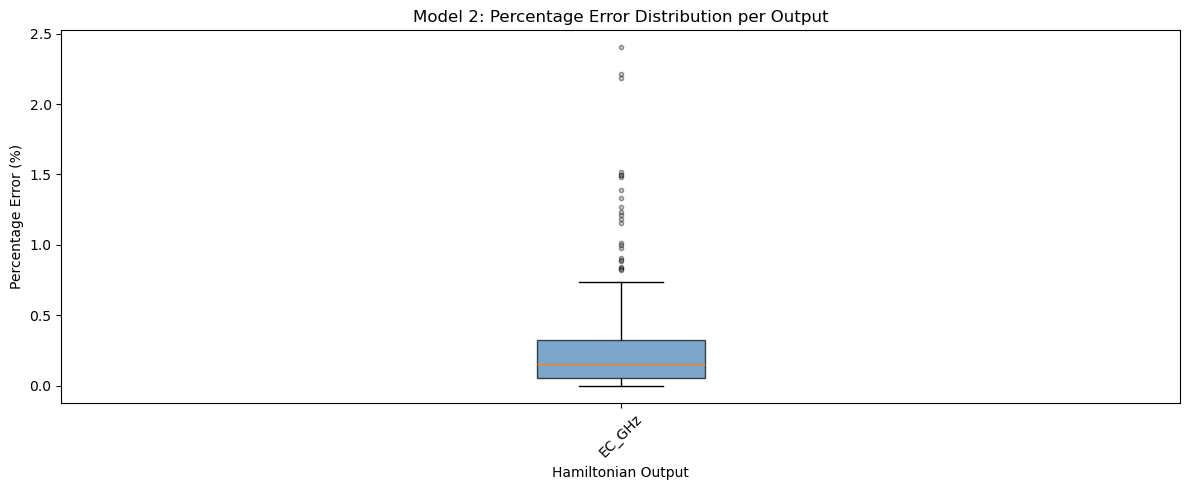

In [10]:
## box plot showing % error distribution per hamiltonian output
fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(data_per_col, labels=short_names, patch_artist=True, showfliers=True,
                flierprops=dict(marker='o', markersize=3, alpha=0.4, markerfacecolor='grey'))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax.set_ylabel('Percentage Error (%)')
ax.set_xlabel('Hamiltonian Output')
ax.set_title('Model 2: Percentage Error Distribution per Output')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'model2_pct_error_boxplot.pdf'))
plt.show()

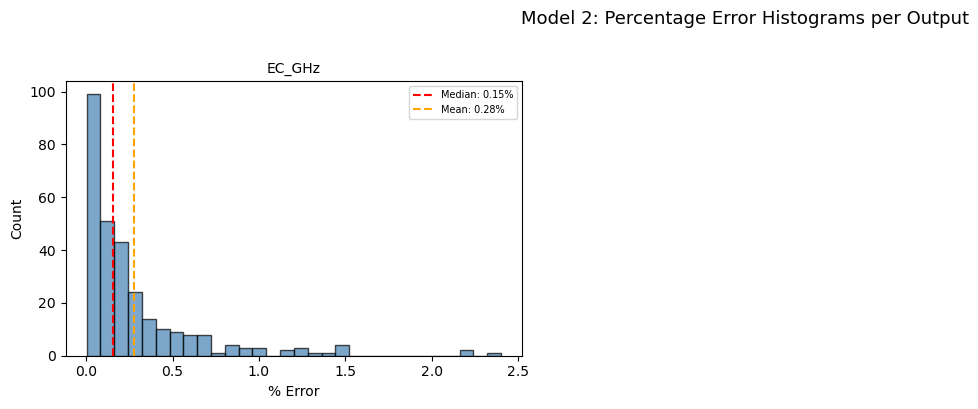

In [11]:
## histogram it too
n_cols_grid = 3
n_rows_grid = math.ceil(n_params / n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows_grid))
axes = axes.ravel()

for j in range(n_params):
    col_pct = pct_errors_unscaled[:, j]
    ax = axes[j]
    ax.hist(col_pct, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(np.median(col_pct), color='red', linestyle='--',
               label=f'Median: {np.median(col_pct):.2f}%')
    ax.axvline(np.mean(col_pct), color='orange', linestyle='--',
               label=f'Mean: {np.mean(col_pct):.2f}%')
    ax.set_title(short_names[j], fontsize=10)
    ax.set_xlabel('% Error')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

## hide unused subplots
for k in range(n_params, len(axes)):
    fig.delaxes(axes[k])

fig.suptitle('Model 2: Percentage Error Histograms per Output', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'model2_pct_error_histograms_per_output.pdf'))
plt.show()

In [12]:
## look at the stats nicely
print(f"{'Output':<25s} {'Median %':>10s} {'Mean %':>10s} {'90th %':>10s} {'Max %':>10s}")
print('-' * 70)
for j in range(n_params):
    col_pct = pct_errors_unscaled[:, j]
    name = short_names[j]
    print(f"{name:<25s} {np.median(col_pct):10.2f} {np.mean(col_pct):10.2f} "
          f"{np.percentile(col_pct, 90):10.2f} {np.max(col_pct):10.2f}")
print('-' * 70)
print(f"{'All outputs':<25s} {np.median(all_pct):10.2f} {np.mean(all_pct):10.2f} "
      f"{np.percentile(all_pct, 90):10.2f} {np.max(all_pct):10.2f}")

Output                      Median %     Mean %     90th %      Max %
----------------------------------------------------------------------
EC_GHz                          0.15       0.28       0.67       2.40
----------------------------------------------------------------------
All outputs                     0.15       0.28       0.67       2.40


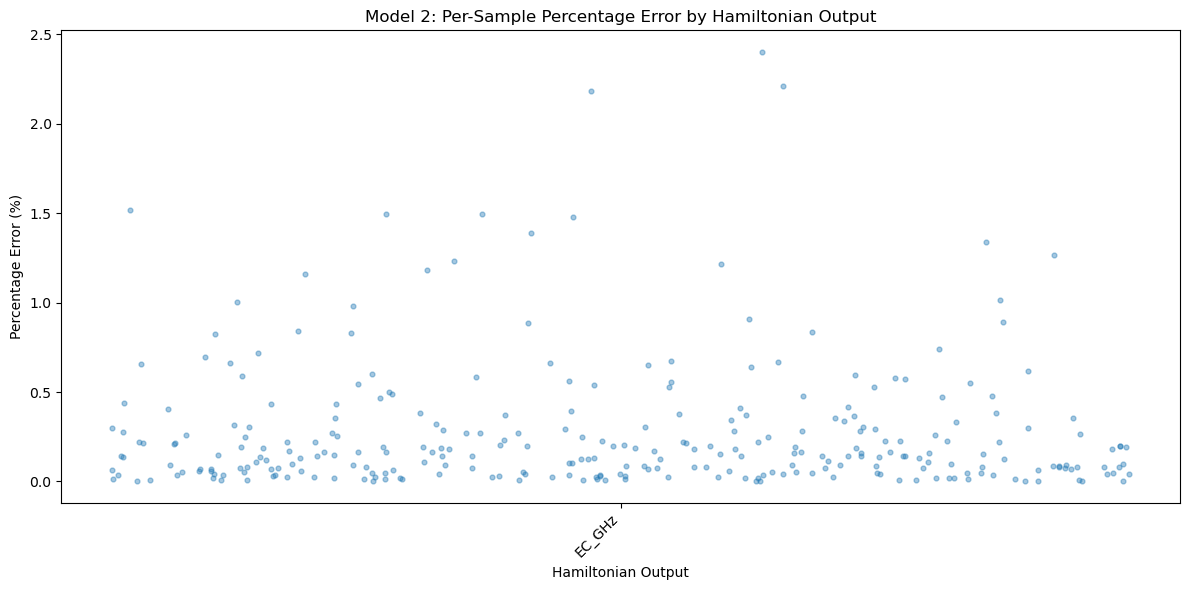

In [13]:
## scatter plot with fancy visulaization of points using this grouping thing

fig, ax = plt.subplots(figsize=(12, 6))
for j in range(n_params):
    col_pct = pct_errors_unscaled[:, j]
    x = np.full_like(col_pct, j) + np.random.uniform(-0.2, 0.2, size=len(col_pct))
    ax.scatter(x, col_pct, alpha=0.4, s=12, label=short_names[j])
ax.set_xticks(range(n_params))
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_ylabel('Percentage Error (%)')
ax.set_xlabel('Hamiltonian Output')
ax.set_title('Model 2: Per-Sample Percentage Error by Hamiltonian Output')
plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'model2_pct_error_scatter.pdf'))
plt.show()